In [1]:
import pandas as pd
print("Đã import thành công thư viện pandas!")

Đã import thành công thư viện pandas!


In [4]:
df = pd.read_csv('BT3.310092301_scoring_credit_linear.csv')

print("=== 5 DÒNG ĐẦU TIÊN CỦA DATASET ===")
display(df.head())

print("\n=== THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU ===")
df.info()

=== 5 DÒNG ĐẦU TIÊN CỦA DATASET ===


,Income,Credit_Score
0,50000,700
1,60000,720
2,42000,650
3,80000,750
4,55000,710



=== THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Income        20 non-null     int64
 1   Credit_Score  20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Đã import thành công numpy, LinearRegression, metric và matplotlib!")

Đã import thành công numpy, LinearRegression, metric và matplotlib!


In [6]:
X = df[['Income']]

y = df['Credit_Score']

model = LinearRegression()

model.fit(X, y)

print("Đã huấn luyện xong mô hình hồi quy tuyến tính!")

Đã huấn luyện xong mô hình hồi quy tuyến tính!


In [7]:
y_pred = model.predict(X)

df_compare = pd.DataFrame({
    'Thu nhập (Income)': df['Income'],
    'Điểm thực tế (Actual y)': y,
    'Điểm dự đoán (Predicted y_pred)': np.round(y_pred, 2),
    'Chênh lệch (Residual)': np.round(y - y_pred, 2)
})

print("=== SO SÁNH GIÁ TRỊ THỰC TẾ VÀ GIÁ TRỊ DỰ ĐOÁN (5 DÒNG ĐẦU) ===")
display(df_compare.head())

=== SO SÁNH GIÁ TRỊ THỰC TẾ VÀ GIÁ TRỊ DỰ ĐOÁN (5 DÒNG ĐẦU) ===


,Thu nhập (Income),Điểm thực tế (Actual y),Điểm dự đoán (Predicted y_pred),Chênh lệch (Residual)
0,50000,700,682.19,17.81
1,60000,720,705.16,14.84
2,42000,650,663.82,-13.82
3,80000,750,751.09,-1.09
4,55000,710,693.68,16.32


In [8]:
intercept = model.intercept_
slope = model.coef_[0]

print("=== CÁC HỆ SỐ CỦA MÔ HÌNH HỒI QUY ===")
print(f"- Hệ số chặn (Intercept / w0) : {intercept:.4f}")
print(f"- Hệ số dốc (Slope / Coef / w1): {slope:.6f}")

print("\n=== KẾT LUẬN HÀM MÔ HÌNH HỒI QUY ===")
print(f"  Credit_Score = {intercept:.4f} + {slope:.6f} * Income")
print("\nÝ nghĩa kinh tế:")
print(f"• Khi thu nhập bằng 0, điểm tín dụng cơ sở ước tính là khoảng {intercept:.2f} điểm.")
print(f"• Cứ mỗi khi thu nhập tăng thêm 1 đơn vị tiền tệ, điểm tín dụng tăng trung bình khoảng {slope:.6f} điểm (hoặc tăng {slope * 10000:.2f} điểm cho mỗi 10,000 đơn vị thu nhập).")

=== CÁC HỆ SỐ CỦA MÔ HÌNH HỒI QUY ===
- Hệ số chặn (Intercept / w0) : 567.3617
- Hệ số dốc (Slope / Coef / w1): 0.002297

=== KẾT LUẬN HÀM MÔ HÌNH HỒI QUY ===
  Credit_Score = 567.3617 + 0.002297 * Income

Ý nghĩa kinh tế:
• Khi thu nhập bằng 0, điểm tín dụng cơ sở ước tính là khoảng 567.36 điểm.
• Cứ mỗi khi thu nhập tăng thêm 1 đơn vị tiền tệ, điểm tín dụng tăng trung bình khoảng 0.002297 điểm (hoặc tăng 22.97 điểm cho mỗi 10,000 đơn vị thu nhập).


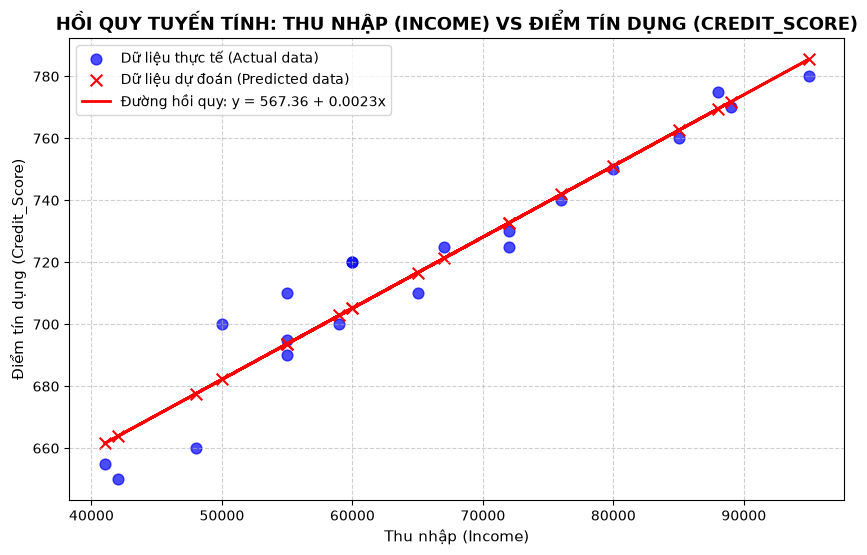

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='blue', s=60, alpha=0.7, label='Dữ liệu thực tế (Actual data)')

plt.scatter(X, y_pred, color='red', marker='x', s=70, label='Dữ liệu dự đoán (Predicted data)')

plt.plot(X, y_pred, color='red', linewidth=2, label=f'Đường hồi quy: y = {intercept:.2f} + {slope:.4f}x')

plt.title('HỒI QUY TUYẾN TÍNH: THU NHẬP (INCOME) VS ĐIỂM TÍN DỤNG (CREDIT_SCORE)', fontsize=13, fontweight='bold')
plt.xlabel('Thu nhập (Income)', fontsize=11)
plt.ylabel('Điểm tín dụng (Credit_Score)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.show()

In [10]:
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("=== CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH ===")
print(f"1. Mean Squared Error (MSE)     : {mse:.4f}")
print(f"2. Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"3. R-squared (R2 Score)          : {r2:.4f} ({r2 * 100:.2f}%)")

print("\n=== NHẬN XÉT ===")
print(f"• Về chỉ số R-squared ({r2:.4f}): Mô hình có độ phù hợp rất cao (Very Good Fit).")
print(f"  Khoảng {r2 * 100:.2f}% sự biến thiên của điểm tín dụng (Credit_Score) được giải thích bởi mức thu nhập (Income).")
print(f"• Về sai số RMSE ({rmse:.4f}): Độ lệch trung bình giữa điểm tín dụng thực tế và điểm tín dụng do mô hình dự đoán chỉ khoảng {rmse:.2f} điểm, là mức sai số tương đối nhỏ so với thang điểm tín dụng (600 - 800 điểm).")
print("=> Kết luận: Thu nhập là một biến dự báo rất mạnh đối với điểm tín dụng trong tập dữ liệu này.")

=== CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH ===
1. Mean Squared Error (MSE)     : 89.5986
2. Root Mean Squared Error (RMSE): 9.4657
3. R-squared (R2 Score)          : 0.9345 (93.45%)

=== NHẬN XÉT ===
• Về chỉ số R-squared (0.9345): Mô hình có độ phù hợp rất cao (Very Good Fit).
  Khoảng 93.45% sự biến thiên của điểm tín dụng (Credit_Score) được giải thích bởi mức thu nhập (Income).
• Về sai số RMSE (9.4657): Độ lệch trung bình giữa điểm tín dụng thực tế và điểm tín dụng do mô hình dự đoán chỉ khoảng 9.47 điểm, là mức sai số tương đối nhỏ so với thang điểm tín dụng (600 - 800 điểm).
=> Kết luận: Thu nhập là một biến dự báo rất mạnh đối với điểm tín dụng trong tập dữ liệu này.
